<img src="https://raw.githubusercontent.com/saceballes/aps_entregas/main/logo_UNSAM.jpg" align="right" width="150" />

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº2

#### Sebastián Ceballes


# Consigna
En esta tarea semanal retomamos la consigna de la tarea anterior, donde simulamos el bloque de cuantización de un ADC de B bits en un rango de  ±VF
 Volts. Ahora vamos a completar la simulación del ADC incluyendo la capacidad de muestrear a fs Hertz.

Para ello se simulará el comportamiento del dispositivo al digitalizar una senoidal contaminada con un nivel predeterminado de ruido. Comenzaremos describiendo los parámetros a ajustar de la senoidal:

frecuencia f0
 arbitraria, por ejemplo f0=fS/N=Δf
 
energía normalizada, es decir energía (o varianza) unitaria
Con respecto a los parámetros de la secuencia de ruido, diremos que:

será de carácter aditivo, es decir la señal que entra al ADC será sR=s+n
. Siendo n
 la secuencia que simula la interferencia, y s
 la senoidal descrita anteriormente.
La potencia del ruido será Pn=kn.Pq
 W siendo el factor k una escala para la potencia del ruido de cuantización Pq=q212
.
finalmente, n
 será incorrelado y Gaussiano.
El ADC que deseamos simular trabajará a una frecuencia de muestreo fS=1000
 Hz y tendrá un rango analógico de ±VF=2
 Volts.

Se pide:

a) Generar el siguiente resultado producto de la experimentación. B = 4 bits, kn=1
.


# Resolución
fs=1000 Hz y N=1000 muestras
como 
\begin{equation}T_{0}=\frac{N}{f_{s}}
\end{equation}
T_0 = 1 segundo
Al configurar una ventana de exactamente $1$ segundo, garantizamos que cualquier señal con una frecuencia entera (como $1\text{ Hz}$, $50\text{ Hz}$ o $500\text{ Hz}$) completará un número exacto de ciclos dentro de nuestro vector.

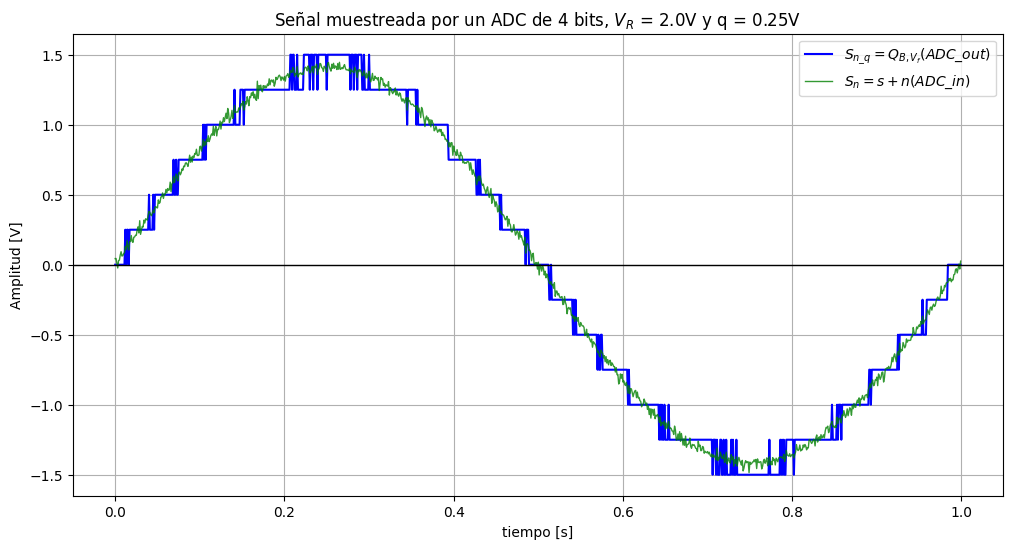

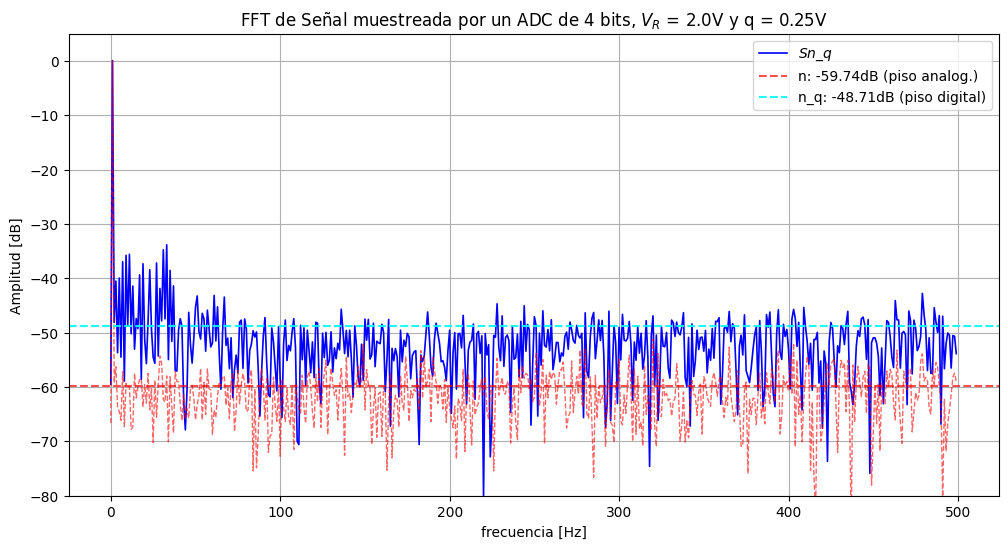

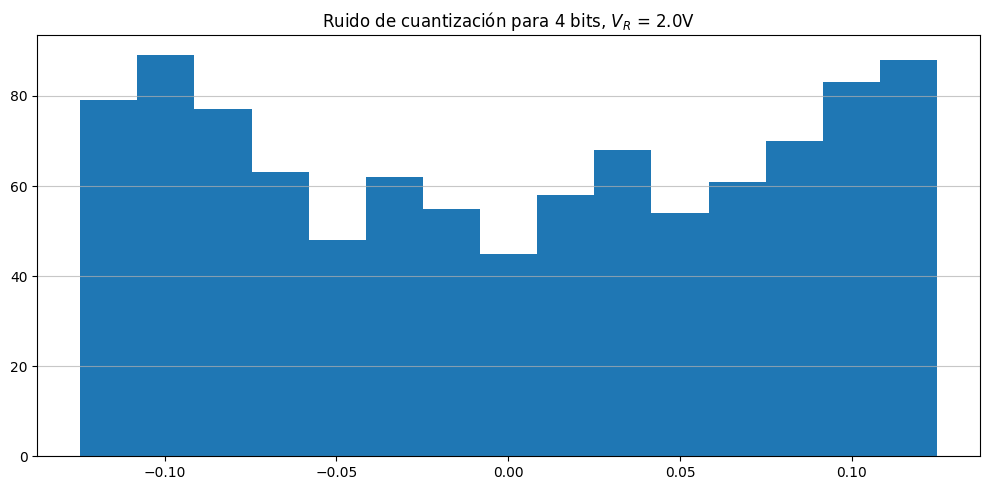

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------- DEFINICION CTES ----------------------
fs = 1000 # Frecuencia muestreo (Hz)
N = 1000  # Cant. muestras
vmax = np.sqrt(2) # Amp max para varianza unitaria (1W)
dc = 0 # Offset
ff = fs / N # Frecuencia sinusoidal (Hz) -> delta_f
ph = 0 # rad

# Parámetros del ADC
n_bits = 4
Vfs = 2.0
q = (2 * Vfs) / (2 ** n_bits)
k_n = 0.1

# ------------------------- FUNCIONES -------------------------
def gen_sin(vmax=1, dc=0, ff=1, ph=0, nn=N, fs=fs):
    """Generador de señal senoidal"""
    tt = np.arange(0, stop=nn/fs, step=1/fs)
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
    return tt, xx

def mi_fft(senial):
    fft_out = np.fft.fft(senial)
    fft_abs = np.abs(fft_out[:N//2]) * (2/N)
    frecuencias = np.arange(N//2) * (fs/N)
    return frecuencias, fft_abs

# ------------------------ MAIN SCRIPT ------------------------
# 1. Generación de la señal original
t, s = gen_sin(vmax=vmax, dc=dc, ff=ff, ph=ph, nn=N, fs=fs)

# 2. Definición del ruido según k_n y paso de cuantización
P_q = (q**2) / 12
P_n = k_n * P_q
sigma = np.sqrt(P_n)

# 3. Suma de ruido y proceso de cuantización
n = np.random.normal(scale=sigma, size=len(t))
sn = s + n
sn_cuantizada = np.round(sn/q) * q
n_q = sn_cuantizada - sn  # Ruido de cuantización resultante

# 4. Análisis en el dominio de la frecuencia (Normalización respecto al máximo)
freq, sn_fft_abs = mi_fft(sn)
ref = np.max(sn_fft_abs)
sn_fft_dB = 20 * np.log10(sn_fft_abs / ref + 1e-12)

freq, sn_cuantizada_fft_abs = mi_fft(sn_cuantizada)
sn_cuantizada_fft_dB = 20 * np.log10(sn_cuantizada_fft_abs / ref + 1e-12)

# Cálculo de los pisos de ruido (promedio de la potencia lineal excluyendo DC y f0)
piso_analog_lineal = np.mean((sn_fft_abs[2:] / ref)**2)
piso_analog_dB = 10 * np.log10(piso_analog_lineal)

piso_digital_lineal = np.mean((sn_cuantizada_fft_abs[2:] / ref)**2)
piso_digital_dB = 10 * np.log10(piso_digital_lineal)

# ------------------------ GRÁFICOS ------------------------
plt.close("all")
titulo_base = f"ADC de {n_bits} bits, $V_R$ = {Vfs}V y q = {q}V"

# Figura 1: Dominio del Tiempo
plt.figure(1, figsize=(12, 6))
plt.plot(t, sn_cuantizada, color="blue", linewidth=1.5, label="$S_{n\_q} = Q_{B,V_f}(ADC\_out)$")
plt.plot(t, sn, color="green", linewidth=1, alpha=0.8, label="$S_n = s+n (ADC\_in)$")
plt.title(f"Señal muestreada por un {titulo_base}")
plt.xlabel("tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.axhline(0, color="black", linewidth=1)
plt.grid(True)
plt.legend(loc='upper right')

# Figura 2: Espectro de Magnitud
plt.figure(2, figsize=(12, 6))
plt.plot(freq, sn_cuantizada_fft_dB, color="blue", linewidth=1.2, label="$Sn\_q$")
plt.plot(freq, sn_fft_dB, color="red", linestyle="--", linewidth=1, alpha=0.6)

# Pisos de ruido horizontales
plt.axhline(piso_analog_dB, color="red", linestyle="--", alpha=0.7, 
            label=f"n: {piso_analog_dB:.2f}dB (piso analog.)")
plt.axhline(piso_digital_dB, color="cyan", linestyle="--", alpha=0.9, 
            label=f"n_q: {piso_digital_dB:.2f}dB (piso digital)")

plt.title(f"FFT de Señal muestreada por un {titulo_base}")
plt.xlabel("frecuencia [Hz]")
plt.ylabel("Amplitud [dB]")
plt.ylim([-80, 5])
plt.grid(True)
plt.legend(loc='upper right')

# Figura 3: Histograma
plt.figure(3, figsize=(10, 5))
plt.hist(n_q, bins=15, color="tab:blue")
plt.title(f"Ruido de cuantización para {n_bits} bits, $V_R$ = {Vfs}V")
plt.grid(axis='y', alpha=0.7)

plt.tight_layout()
plt.show()
